In [20]:
import pandas as pd
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

df.head()


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [21]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [24]:
df.loc[df['Health_Impacts'].isna(),'Health_Impacts']='No Health Impact'

In [25]:
(df['Health_Impacts']=='No Health Impact').sum()

3218

In [27]:
df['Health_Impacts'].value_counts()

Health_Impacts
No Health Impact                                 3218
Poor Sleep                                       2268
Poor Sleep, Eye Strain                            979
Eye Strain                                        644
Poor Sleep, Anxiety                               608
Poor Sleep, Obesity Risk                          452
Anxiety                                           385
Poor Sleep, Eye Strain, Anxiety                   258
Obesity Risk                                      252
Poor Sleep, Eye Strain, Obesity Risk              188
Eye Strain, Anxiety                               135
Eye Strain, Obesity Risk                          106
Poor Sleep, Anxiety, Obesity Risk                  78
Anxiety, Obesity Risk                              69
Poor Sleep, Eye Strain, Anxiety, Obesity Risk      37
Eye Strain, Anxiety, Obesity Risk                  35
Name: count, dtype: int64

In [28]:
df['Health_Impacts'].unique()

array(['Poor Sleep, Eye Strain', 'Poor Sleep', 'No Health Impact',
       'Poor Sleep, Anxiety', 'Poor Sleep, Obesity Risk', 'Eye Strain',
       'Obesity Risk', 'Anxiety', 'Poor Sleep, Anxiety, Obesity Risk',
       'Eye Strain, Obesity Risk', 'Eye Strain, Anxiety, Obesity Risk',
       'Anxiety, Obesity Risk', 'Poor Sleep, Eye Strain, Obesity Risk',
       'Poor Sleep, Eye Strain, Anxiety',
       'Poor Sleep, Eye Strain, Anxiety, Obesity Risk',
       'Eye Strain, Anxiety'], dtype=object)

In [29]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [30]:
df['Gender'].value_counts()

Gender
Male      4942
Female    4770
Name: count, dtype: int64

In [31]:
df['Primary_Device'].unique()#

array(['Smartphone', 'Laptop', 'TV', 'Tablet'], dtype=object)

In [32]:
df['Primary_Device'].value_counts()

Primary_Device
Smartphone    4568
TV            2487
Laptop        1433
Tablet        1224
Name: count, dtype: int64

In [33]:
df['Exceeded_Recommended_Limit'].unique()

array([ True, False])

In [34]:
df["Age_Band"] = pd.cut(
    df["Age"],
    bins=[4, 8, 11, 14, 18],
    labels=["Early Childhood", "Pre-Teen", "Early Teen", "Late Teen"]
)

In [38]:
df[['Age','Age_Band']].head()

,Age,Age_Band
0,14,Early Teen
1,11,Pre-Teen
2,18,Late Teen
3,15,Late Teen
4,12,Early Teen


In [39]:
df['Age_Band'].value_counts()

Age_Band
Late Teen          3499
Early Teen         2673
Pre-Teen           2628
Early Childhood     912
Name: count, dtype: int64

In [40]:
df['Primary_Device'].value_counts()

Primary_Device
Smartphone    4568
TV            2487
Laptop        1433
Tablet        1224
Name: count, dtype: int64

In [41]:
# create activity_type column
df['activity_type'] = ''

# assign values based on ratio
df.loc[df['Educational_to_Recreational_Ratio'] > 1, 'activity_type'] = 'Educational Usage'
df.loc[df['Educational_to_Recreational_Ratio'] < 1, 'activity_type'] = 'Recreational Usage'
df.loc[df['Educational_to_Recreational_Ratio'] == 1, 'activity_type'] = 'Balanced Usage'

# count of each activity type
counts = df['activity_type'].value_counts()
print(counts)

# total records
total = len(df)
print("Total Records:", total)

# percentage share of each activity type
activity_share = (counts / total) * 100
print(activity_share)

activity_type
Recreational Usage    9712
Name: count, dtype: int64
Total Records: 9712
activity_type
Recreational Usage    100.0
Name: count, dtype: float64


In [43]:
#health_issue_present - Derived field

In [48]:
df['health_issue_present'] = df['Health_Impacts'].apply(
    lambda x: 'no health issue' if x == 'None' else 'Health Issue'
)
df.loc[df['Health_Impacts']=='No Health Impact','health_issue_present']='No Health Issue'
print(df['health_issue_present'].value_counts())

health_issue_present
Health Issue       6494
No Health Issue    3218
Name: count, dtype: int64


In [ ]:
#device type - Derived field

In [50]:
df['device_type']=''
df.loc[df['Primary_Device']=='Smartphone','device_type']='portable'
df.loc[df['Primary_Device']=='Laptop','device_type']='portable'
df.loc[df['Primary_Device']=='Tablet','device_type']='portable'
df.loc[df['Primary_Device']=='TV','device_type']='wall-mounted'
df[['Primary_Device','device_type']].head()

,Primary_Device,device_type
0,Smartphone,portable
1,Laptop,portable
2,TV,wall-mounted
3,Laptop,portable
4,Smartphone,portable


In [51]:
#Duration - Derived field

In [52]:
# create duration category
df['Duration_Category'] = ''

df.loc[df['Avg_Daily_Screen_Time_hr'] < 2, 'Duration_Category'] = 'Low (0-2 hrs)'
df.loc[(df['Avg_Daily_Screen_Time_hr'] >= 2) & 
       (df['Avg_Daily_Screen_Time_hr'] < 4), 'Duration_Category'] = 'Moderate (2-4 hrs)'
df.loc[(df['Avg_Daily_Screen_Time_hr'] >= 4) & 
       (df['Avg_Daily_Screen_Time_hr'] < 6), 'Duration_Category'] = 'High (4-6 hrs)'
df.loc[df['Avg_Daily_Screen_Time_hr'] >= 6, 'Duration_Category'] = 'Very High (6+ hrs)'

print(df['Duration_Category'].value_counts())

Duration_Category
High (4-6 hrs)        4606
Moderate (2-4 hrs)    2914
Very High (6+ hrs)    1366
Low (0-2 hrs)          826
Name: count, dtype: int64


In [ ]:
#Usage - Derived field

In [55]:
# create Usage_Dominance column
df['Usage_Dominance'] = ''

df.loc[df['Educational_to_Recreational_Ratio'] > 1, 'Usage_Dominance'] = 'Education Dominant'
df.loc[df['Educational_to_Recreational_Ratio'] < 1, 'Usage_Dominance'] = 'Recreation Dominant'
df.loc[df['Educational_to_Recreational_Ratio'] == 1, 'Usage_Dominance'] = 'Balanced'

print(df['Usage_Dominance'].value_counts())

Usage_Dominance
Recreation Dominant    9712
Name: count, dtype: int64


In [56]:
# create recreation_intensity column
df['recreation_intensity'] = 'Normal'

# strongly recreational (ratio < 0.67)
df.loc[df['Educational_to_Recreational_Ratio'] < 0.67, 
       'recreation_intensity'] = 'Highly Recreational'

print(df['recreation_intensity'].value_counts())

recreation_intensity
Highly Recreational    9712
Name: count, dtype: int64


In [57]:
# create education_intensity column
df['education_intensity'] = 'Normal'

# highly educational (ratio > 1.5)
df.loc[df['Educational_to_Recreational_Ratio'] > 1.5, 
       'education_intensity'] = 'Highly Educational'

print(df['education_intensity'].value_counts())

education_intensity
Normal    9712
Name: count, dtype: int64


In [ ]:
#Weekday - Derived Field

In [58]:
# calculate mean screen time
mean_screen_time = df['Avg_Daily_Screen_Time_hr'].mean()

# create weekday_flag column
df['weekday_flag'] = ''

# assign labels based on mean comparison
df.loc[df['Avg_Daily_Screen_Time_hr'] > mean_screen_time, 'weekday_flag'] = 'weekend'
df.loc[df['Avg_Daily_Screen_Time_hr'] <= mean_screen_time, 'weekday_flag'] = 'weekday'

# print counts
print(df['weekday_flag'].value_counts())

# preview
print(df[['Avg_Daily_Screen_Time_hr', 'weekday_flag']].head())

weekday_flag
weekend    5048
weekday    4664
Name: count, dtype: int64
   Avg_Daily_Screen_Time_hr weekday_flag
0                      3.99      weekday
1                      4.61      weekend
2                      3.73      weekday
3                      1.21      weekday
4                      5.89      weekend


In [59]:
print("Updated Dataset")
df.head()

Updated Dataset


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,activity_type,health_issue_present,device_type,Duration_Category,Usage_Dominance,recreation_intensity,education_intensity,weekday_flag
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Early Teen,Recreational Usage,Health Issue,portable,Moderate (2-4 hrs),Recreation Dominant,Highly Recreational,Normal,weekday
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Pre-Teen,Recreational Usage,Health Issue,portable,High (4-6 hrs),Recreation Dominant,Highly Recreational,Normal,weekend
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Late Teen,Recreational Usage,Health Issue,wall-mounted,Moderate (2-4 hrs),Recreation Dominant,Highly Recreational,Normal,weekday
3,15,Female,1.21,Laptop,False,0.39,No Health Impact,Urban,Late Teen,Recreational Usage,No Health Issue,portable,Low (0-2 hrs),Recreation Dominant,Highly Recreational,Normal,weekday
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Early Teen,Recreational Usage,Health Issue,portable,High (4-6 hrs),Recreation Dominant,Highly Recreational,Normal,weekend


In [60]:
#Univariate and Bivariate Analysis


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

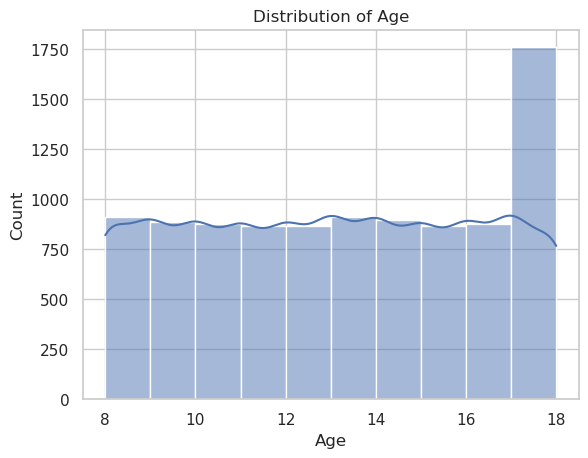

In [64]:
#Histogram 
plt.figure()
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Distribution of Age')
plt.show()

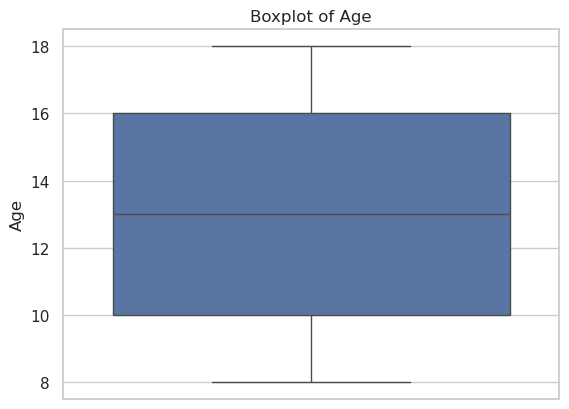

In [65]:
#Boxplot
plt.figure()
sns.boxplot(y=df['Age'])
plt.title('Boxplot of Age')
plt.show()

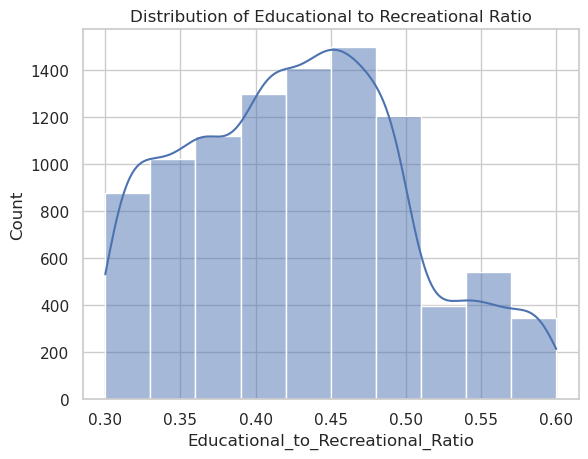

In [67]:
#Educational_to_Recreational_Ratio (Numeric)
plt.figure()
sns.histplot(df['Educational_to_Recreational_Ratio'], bins=10, kde=True)
plt.title('Distribution of Educational to Recreational Ratio')
plt.show()

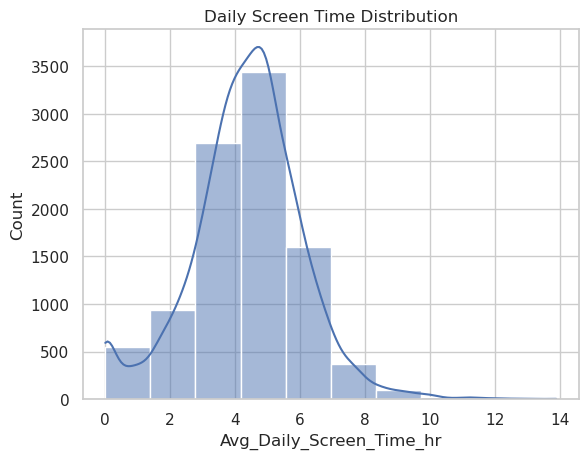

In [68]:
plt.figure()
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=10, kde=True)
plt.title('Daily Screen Time Distribution')
plt.show()

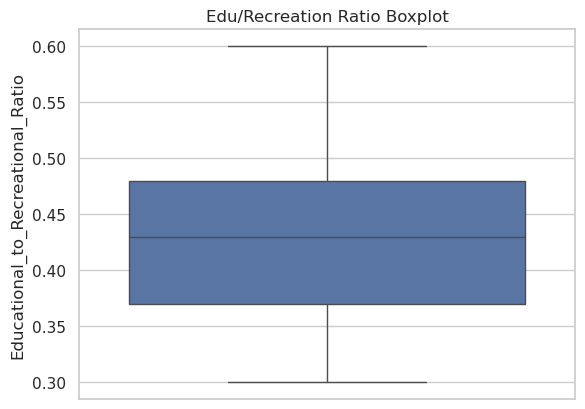

In [69]:
plt.figure()
sns.boxplot(y=df['Educational_to_Recreational_Ratio'])
plt.title('Edu/Recreation Ratio Boxplot')
plt.show()

In [70]:
#Screen TIme

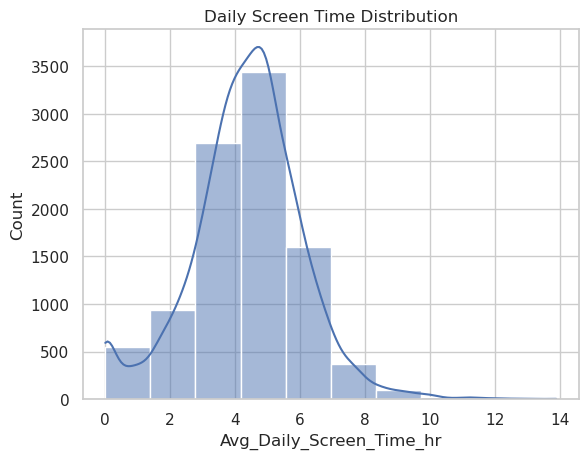

In [71]:
plt.figure()
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=10, kde=True)
plt.title('Daily Screen Time Distribution')
plt.show()


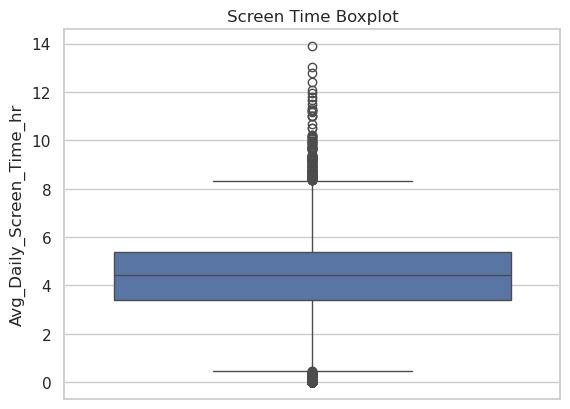

In [72]:
plt.figure()
sns.boxplot(y=df['Avg_Daily_Screen_Time_hr'])
plt.title('Screen Time Boxplot')
plt.show()

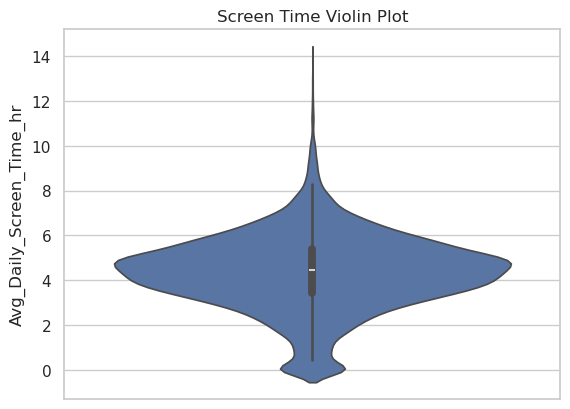

In [73]:
plt.figure()
sns.violinplot(y=df['Avg_Daily_Screen_Time_hr'])
plt.title('Screen Time Violin Plot')
plt.show()

In [74]:
#CATEGORICAL VARIABLES

In [76]:
#Gender

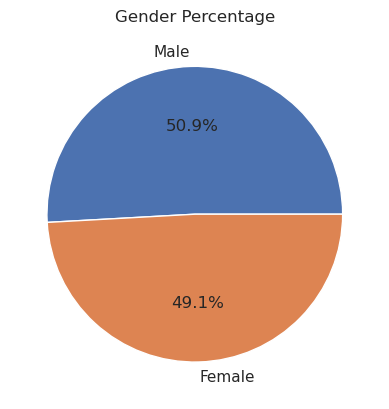

In [77]:
plt.figure()
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Gender Percentage')
plt.ylabel('')
plt.show()

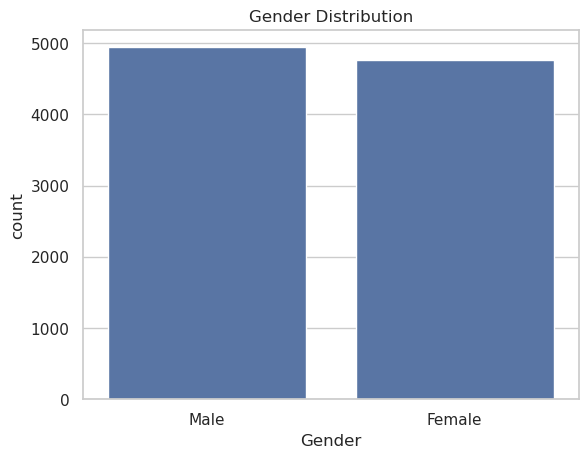

In [78]:
plt.figure()
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

In [79]:
#Primary Device

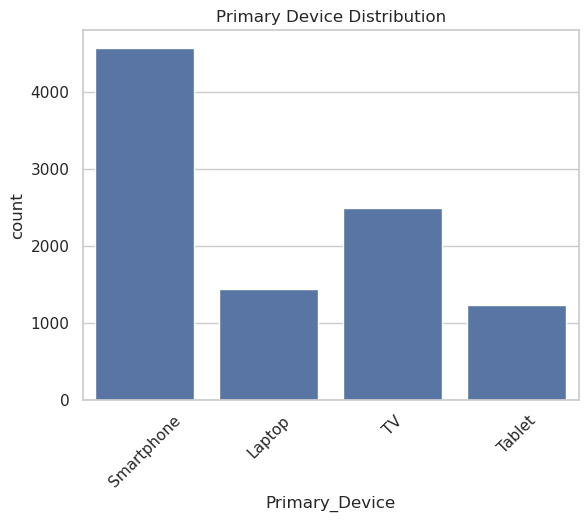

In [80]:
plt.figure()
sns.countplot(x='Primary_Device', data=df)
plt.title('Primary Device Distribution')
plt.xticks(rotation=45)
plt.show()

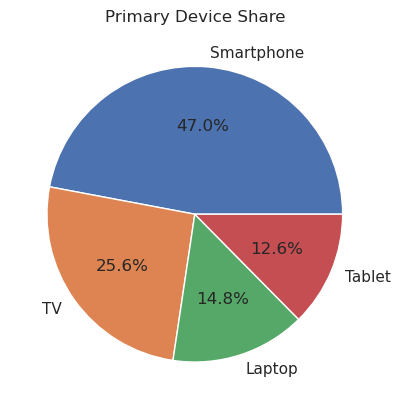

In [81]:
plt.figure()
df['Primary_Device'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Primary Device Share')
plt.ylabel('')
plt.show()

In [82]:
#Exceeded Recommended Limit

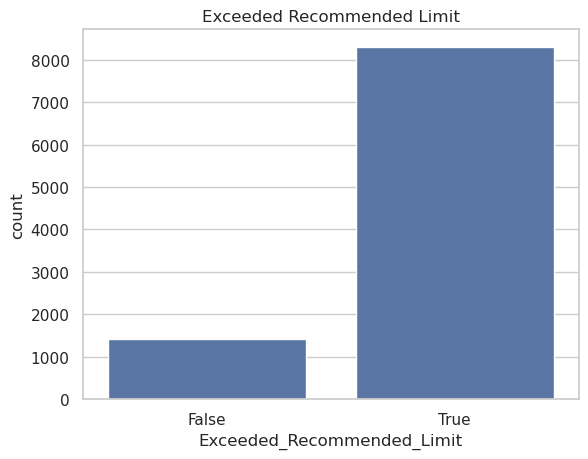

In [83]:
plt.figure()
sns.countplot(x='Exceeded_Recommended_Limit', data=df)
plt.title('Exceeded Recommended Limit')
plt.show()

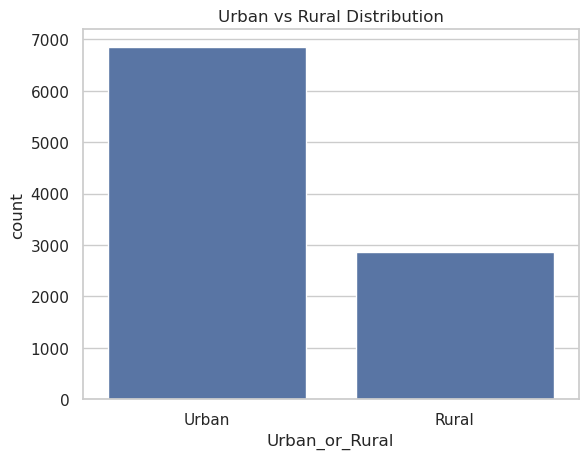

In [84]:
#Urban_Rural
plt.figure()
sns.countplot(x='Urban_or_Rural', data=df)
plt.title('Urban vs Rural Distribution')
plt.show()

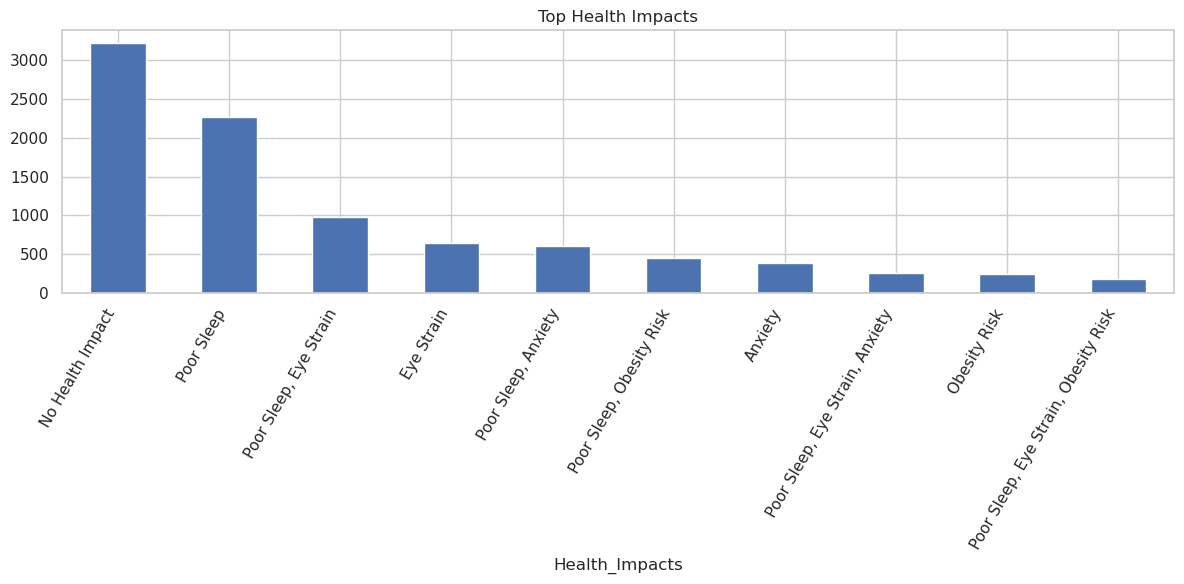

In [87]:
#Health Impacts
plt.figure(figsize=(12,6))

df['Health_Impacts'].value_counts().head(10).plot(kind='bar')

plt.title('Top Health Impacts')
plt.xticks(rotation=60, ha='right')   # rotate + align right
plt.tight_layout()                    # prevent cutting
plt.show()

In [88]:
#Bivariate Analysis

In [89]:
#NUMERIC vs NUMERIC

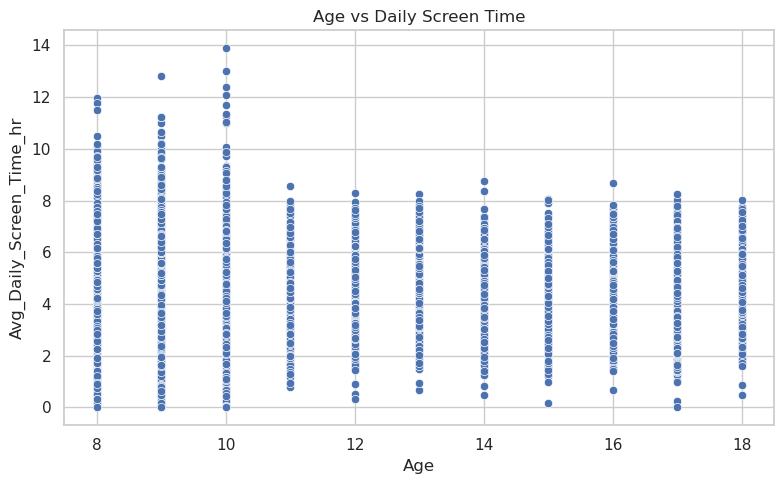

In [90]:
#Age vs Screen Time (Scatter Plot)
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title('Age vs Daily Screen Time')
plt.tight_layout()
plt.show()

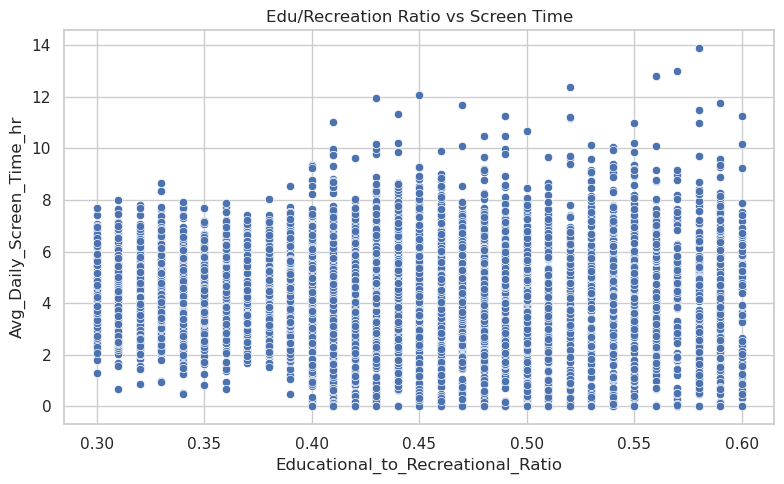

In [91]:
#Ratio vs Screen Time (Scatter Plot)
plt.figure(figsize=(8,5))
sns.scatterplot(x='Educational_to_Recreational_Ratio',
                y='Avg_Daily_Screen_Time_hr',
                data=df)
plt.title('Edu/Recreation Ratio vs Screen Time')
plt.tight_layout()
plt.show()

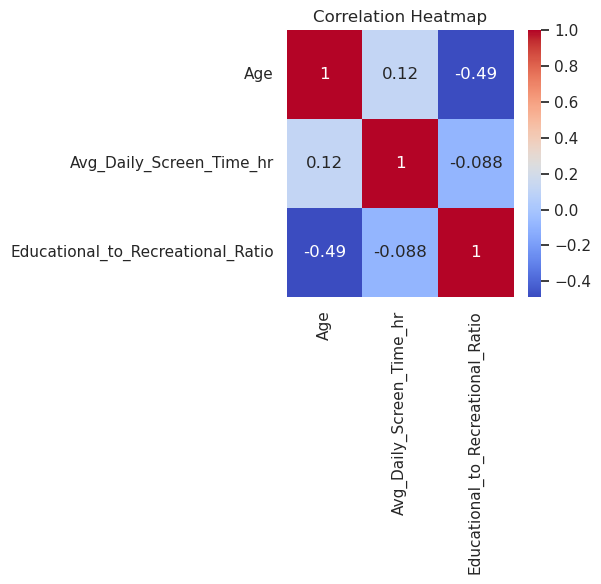

In [96]:
#Correlation Heatmap (All Numeric)
plt.figure(figsize=(6,6))
numeric_cols = df[['Age',
                   'Avg_Daily_Screen_Time_hr',
                   'Educational_to_Recreational_Ratio']]

sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [97]:
#CATEGORICAL vs NUMERIC

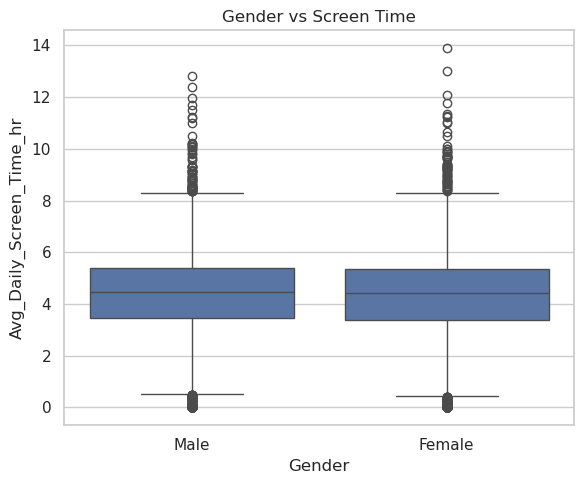

In [99]:
#Gender vs Screen Time (Boxplot)
plt.figure(figsize=(6,5))
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title('Gender vs Screen Time')
plt.tight_layout()
plt.show()

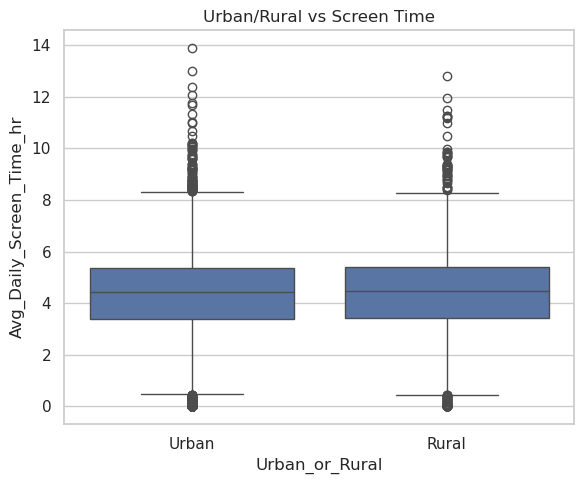

In [100]:
#Urban/Rural vs Screen Time
plt.figure(figsize=(6,5))
sns.boxplot(x='Urban_or_Rural',
            y='Avg_Daily_Screen_Time_hr',
            data=df)
plt.title('Urban/Rural vs Screen Time')
plt.tight_layout()
plt.show()


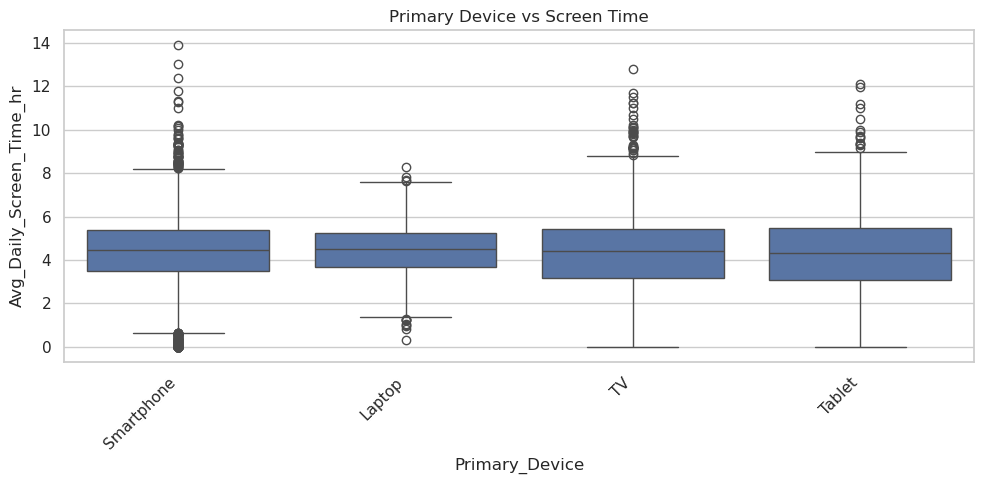

In [101]:
#Primary Device vs Screen Time
plt.figure(figsize=(10,5))
sns.boxplot(x='Primary_Device',
            y='Avg_Daily_Screen_Time_hr',
            data=df)

plt.xticks(rotation=45, ha='right')
plt.title('Primary Device vs Screen Time')
plt.tight_layout()
plt.show()

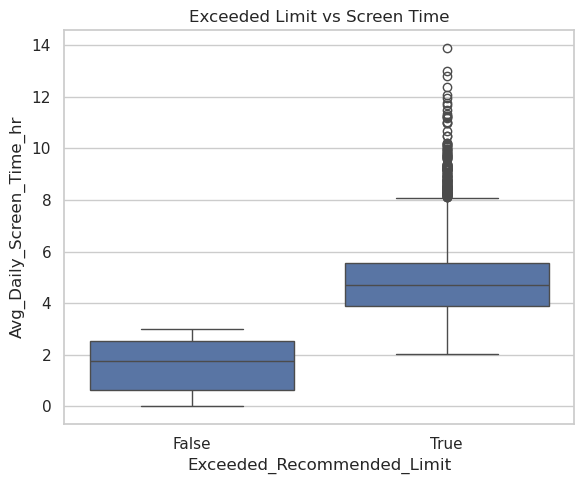

In [102]:
#Exceeded Limit vs Screen Time
plt.figure(figsize=(6,5))
sns.boxplot(x='Exceeded_Recommended_Limit',
            y='Avg_Daily_Screen_Time_hr',
            data=df)

plt.title('Exceeded Limit vs Screen Time')
plt.tight_layout()
plt.show()

In [103]:
#CATEGORICAL vs CATEGORICAL

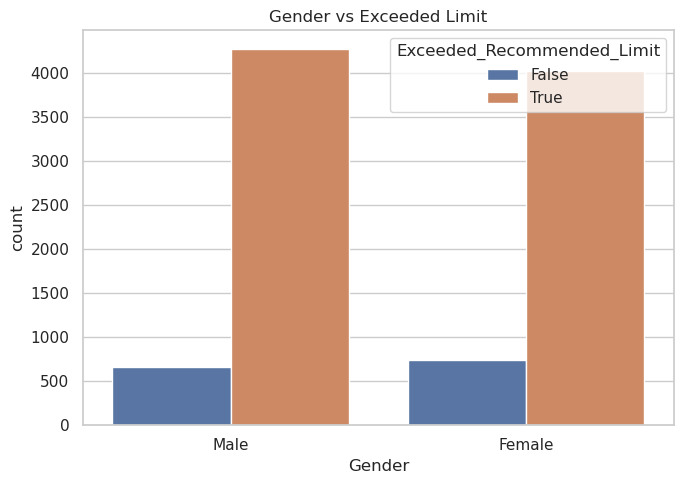

In [104]:
#Gender vs Exceeded Limit (Countplot)
plt.figure(figsize=(7,5))
sns.countplot(x='Gender',
              hue='Exceeded_Recommended_Limit',
              data=df)

plt.title('Gender vs Exceeded Limit')
plt.tight_layout()
plt.show()

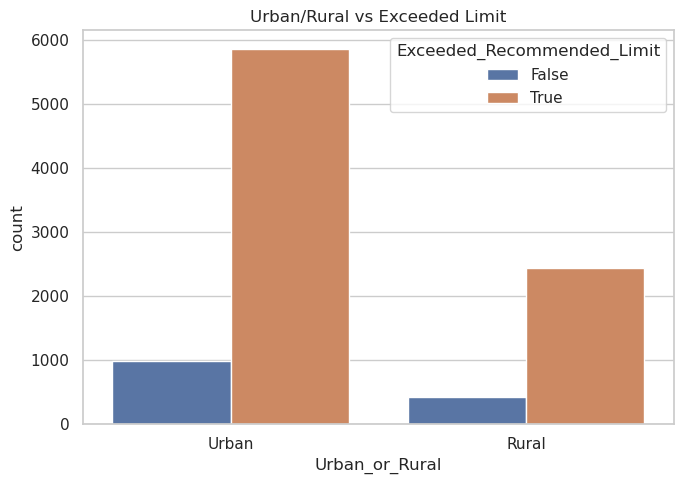

In [105]:
#Urban/Rural vs Exceeded Limit
plt.figure(figsize=(7,5))
sns.countplot(x='Urban_or_Rural',
              hue='Exceeded_Recommended_Limit',
              data=df)

plt.title('Urban/Rural vs Exceeded Limit')
plt.tight_layout()
plt.show()

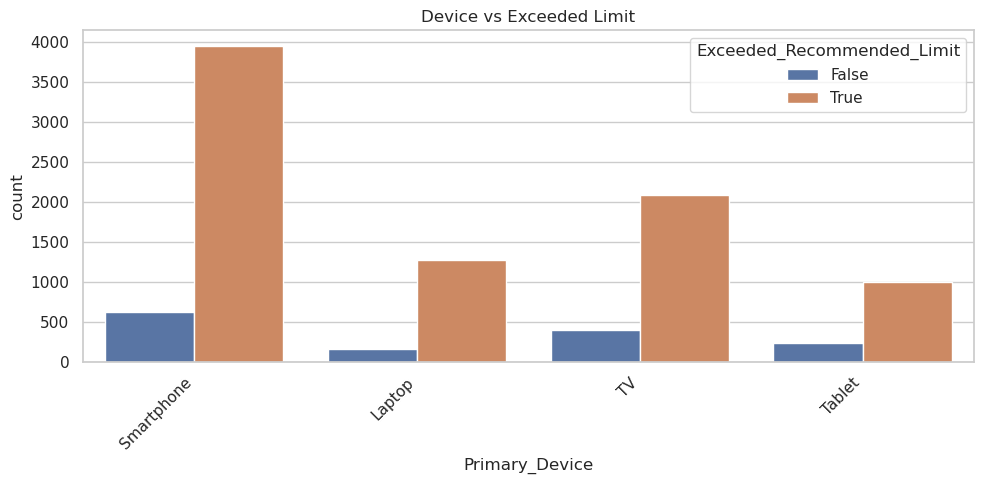

In [106]:
#Device vs Exceeded Limit
plt.figure(figsize=(10,5))
sns.countplot(x='Primary_Device',
              hue='Exceeded_Recommended_Limit',
              data=df)

plt.xticks(rotation=45, ha='right')
plt.title('Device vs Exceeded Limit')
plt.tight_layout()
plt.show()

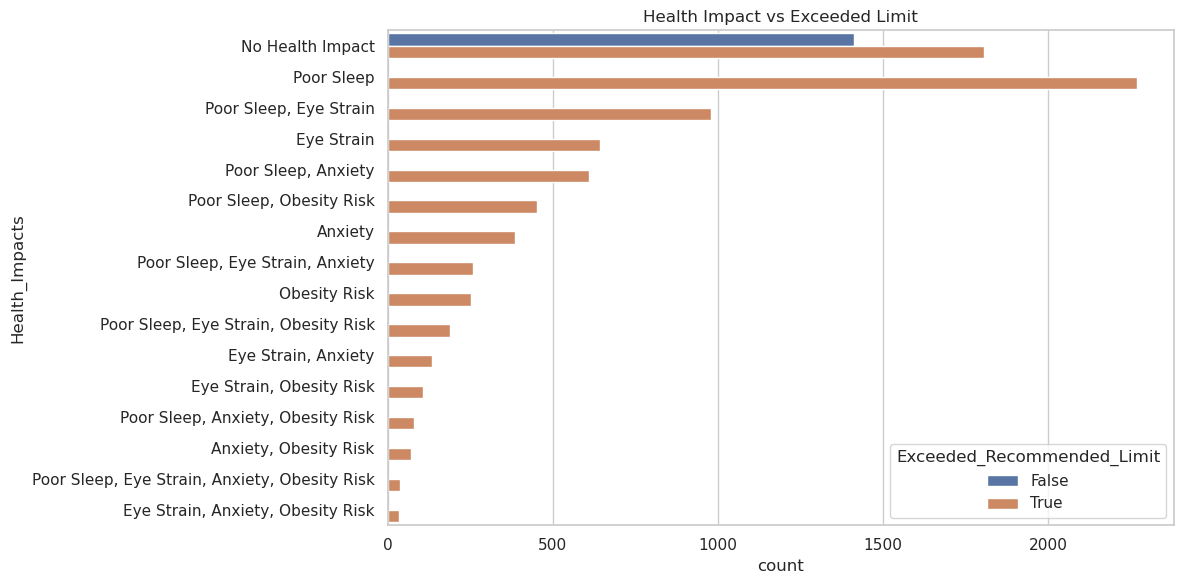

In [107]:
#Health Impact vs Exceeded Limit
plt.figure(figsize=(12,6))
sns.countplot(y='Health_Impacts',
              hue='Exceeded_Recommended_Limit',
              data=df,
              order=df['Health_Impacts'].value_counts().index)

plt.title('Health Impact vs Exceeded Limit')
plt.tight_layout()
plt.show()

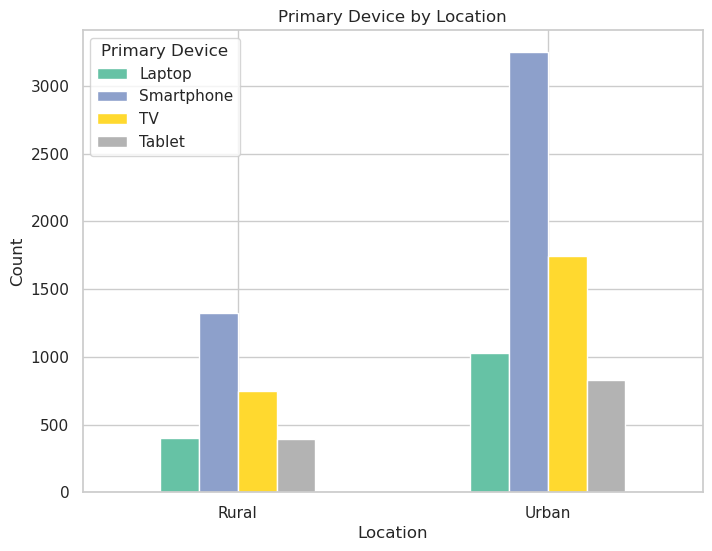

In [113]:
pd.crosstab(df['Urban_or_Rural'], df['Primary_Device']).plot(
    kind='bar',
    figsize=(8,6),
    rot=0,
    colormap='Set2'
)

plt.title("Primary Device by Location")
plt.xlabel("Location")
plt.ylabel("Count")
plt.legend(title="Primary Device")
plt.show()

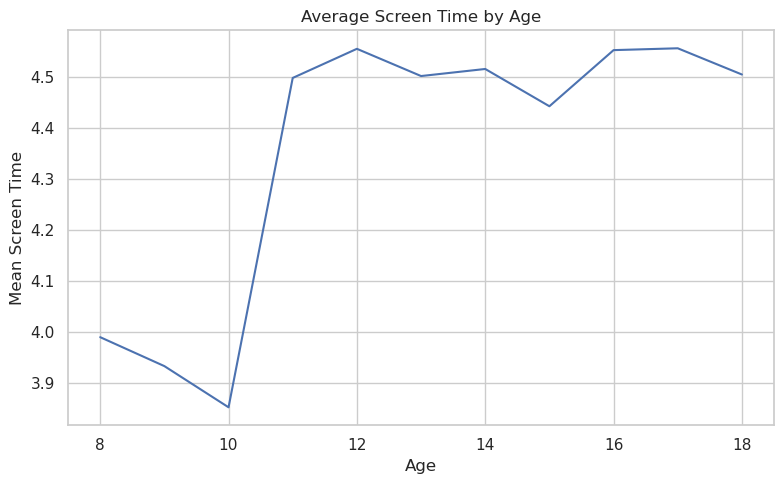

In [114]:
#Age vs Screen Time (Line – Mean by Age)
plt.figure(figsize=(8,5))
mean_by_age = df.groupby('Age')['Avg_Daily_Screen_Time_hr'].mean()
mean_by_age.plot()

plt.title('Average Screen Time by Age')
plt.xlabel('Age')
plt.ylabel('Mean Screen Time')
plt.tight_layout()
plt.show()

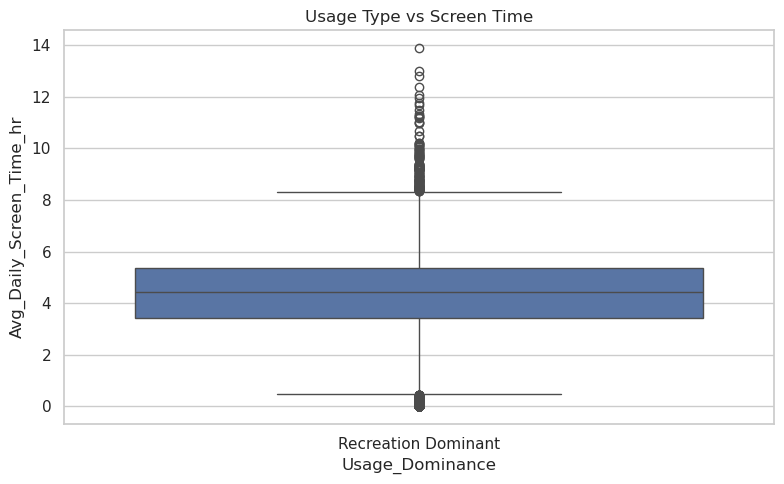

In [115]:
#Ratio Category vs Screen Time
plt.figure(figsize=(8,5))
sns.boxplot(x='Usage_Dominance',
            y='Avg_Daily_Screen_Time_hr',
            data=df)

plt.title('Usage Type vs Screen Time')
plt.tight_layout()
plt.show()